# Trader Performance vs Market Sentiment Analysis

**Candidate:** Anjum Kousar Anantapuram  
**Role:** Data Science / Analytics Intern – Round 0 Assignment  

## Objective
The objective of this analysis is to examine how market sentiment (Fear vs Greed) relates to trader behavior and performance on the Hyperliquid platform. The goal is to identify patterns and insights that could help inform smarter trading strategies.

## Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Part A — Data preparation 
## 1. Loading the datasets

In this step, the two datasets used for the analysis are loaded into the notebook.

- The first dataset contains the daily Bitcoin market sentiment classification as **Fear** or **Greed**.
- The second dataset contains historical trader activity data from **Hyperliquid**.

The purpose of loading these datasets is to inspect their structure and prepare them for further cleaning and analysis.

In [5]:
sentiment_df = pd.read_csv("fear_greed_index.csv")
trader_df = pd.read_csv("historical_data.csv")

## Display first few rows 

In [7]:
sentiment_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [8]:
trader_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


## Dataset Overview

In this section, we inspect the basic structure of both datasets.  
This includes checking the number of rows and columns, previewing the data, and identifying any missing values or duplicates that may need to be handled during data preparation.

In [10]:
# Shape of datasets (rows and columns)
print("Sentiment Dataset Shape:", sentiment_df.shape)
print("Trader Dataset Shape:", trader_df.shape)

Sentiment Dataset Shape: (2644, 4)
Trader Dataset Shape: (211224, 16)


In [11]:
# Column names
print("\nSentiment Dataset Columns:")
print(sentiment_df.columns)

print("\nTrader Dataset Columns:")
print(trader_df.columns)


Sentiment Dataset Columns:
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

Trader Dataset Columns:
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [12]:
# Missing values
print("\nMissing values in Sentiment Dataset:")
print(sentiment_df.isnull().sum())

print("\nMissing values in Trader Dataset:")
print(trader_df.isnull().sum())


Missing values in Sentiment Dataset:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing values in Trader Dataset:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [13]:
# Check duplicates
print("\nDuplicate rows in Sentiment Dataset:", sentiment_df.duplicated().sum())
print("Duplicate rows in Trader Dataset:", trader_df.duplicated().sum())


Duplicate rows in Sentiment Dataset: 0
Duplicate rows in Trader Dataset: 0


## Observations

From the dataset inspection:

- The **Fear/Greed sentiment dataset** has no missing values.
- The **trader dataset** also does not contain missing values.
- No duplicate rows were found in either dataset.

Since the datasets are clean, no additional preprocessing is required for handling missing values or duplicates at this stage.

## 2. Preparing the Date Column by converting the TimeStamps

The trader dataset contains a timestamp column called **Timestamp IST**, which includes both date and time.

The sentiment dataset already has a **date column**.

To match both datasets, we convert the trader timestamp into a date format so that both datasets can be aligned using the same date.

In [16]:
# Convert trader timestamp to datetime (day first format)
trader_df['Timestamp IST'] = pd.to_datetime(trader_df['Timestamp IST'], dayfirst=True)

# Extract date
trader_df['date'] = trader_df['Timestamp IST'].dt.date

# Convert sentiment date column
sentiment_df['date'] = pd.to_datetime(sentiment_df['date']).dt.date

trader_df[['Timestamp IST','date']].head()

,Timestamp IST,date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [17]:
trader_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


## 3. Merging Trader Data with Market Sentiment

Now that both datasets have a common **date column**, we combine them together.

This step attaches the market sentiment (Fear or Greed) to each trade based on the date.  
After merging, every trade record will also include the sentiment of the market on that day.

This will help us analyze how trader behavior and performance change during Fear and Greed periods.

In [19]:
# Merge trader data with sentiment data using the date column
merged_df = pd.merge(trader_df, sentiment_df[['date','classification']], on='date', how='left')
merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


### Creating Key Metrics
### 3.1 Daily PnL per trader

To understand trader performance and behavior, we create some useful metrics from the merged dataset.

The first metric we compute is **daily PnL per trader**.  
This helps us see how much profit or loss each trader made on a given day.

In [21]:
daily_pnl = merged_df.groupby(['Account', 'date'])['Closed PnL'].sum().reset_index()
daily_pnl.head()

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1


### 3.2. Win Rate

Win rate shows the percentage of trades that ended in profit.

A trade is considered a winning trade if the **Closed PnL is greater than 0**.  
This metric helps us understand how often traders make profitable trades.

In [23]:
# Create a column to identify winning trades
merged_df['is_win'] = merged_df['Closed PnL'] > 0
# Calculate win rate
win_rate = merged_df['is_win'].mean()
print("Overall Win Rate:", win_rate)

Overall Win Rate: 0.4112648183918494


### Average Trade Size

Average trade size shows how big the trades usually are.

We calculate this using the **Size USD** column, which tells us the value of each trade in US dollars.  
By finding the average, we can understand the typical trade size used by traders.

In [25]:
# Calculate average trade size in USD
avg_trade_size = merged_df['Size USD'].mean()
print("Average Trade Size (USD):", avg_trade_size)

Average Trade Size (USD): 5639.4512103738225


### 3.3. Leverage Distribution

Leverage means using borrowed money to increase the size of a trade.  
It allows traders to control a larger position with a smaller amount of their own money.

In the dataset provided for this assignment, there is no column named **Leverage**.  
Because of this, leverage distribution cannot be analyzed in this project.


In [27]:
# Check if leverage column exists
print(merged_df.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'classification', 'is_win'],
      dtype='object')


### 3.4. Number of Trades per Day

This metric shows how many trades are made each day.
By counting the number of trades for every date, we can see how active traders are on different days.

In [29]:
# Count number of trades per day
trades_per_day = merged_df.groupby('date').size().reset_index(name='number_of_trades')

# View first few rows
trades_per_day.head()

,date,number_of_trades
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


### 3.5. Long / Short Ratio

In trading, a **long position** means the trader expects the price to go up.  
A **short position** means the trader expects the price to go down.

In this step, we check how many long and short trades were made.  
This helps us understand whether traders are mostly betting on prices going up or down.

In [31]:
# Count long and short trades
long_short_counts = merged_df['Side'].value_counts()
long_short_counts

Side
SELL    108528
BUY     102696
Name: count, dtype: int64

### Meaning:

BUY → Long trades,
SELL → Short trades.
From this we understand whether traders are more bullish or bearish.

# Part B — Analysis
## 1. Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?
In this section, we compare trader performance during **Fear** and **Greed** market conditions.

We analyze the average profit or loss (PnL) for trades that happened on Fear days and Greed days.  
This helps us understand if traders perform differently depending on market sentiment.

In [34]:
# Average PnL during Fear vs Greed days
pnl_by_sentiment = merged_df.groupby('classification')['Closed PnL'].mean().reset_index()
pnl_by_sentiment

,classification,Closed PnL
0,Extreme Fear,34.537862
1,Extreme Greed,67.892861
2,Fear,54.290400
3,Greed,42.743559
4,Neutral,34.307718


## 2. Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?
In this section, we examine whether traders change their behavior depending on market sentiment.

We compare trading activity during Fear and Greed days by looking at trade frequency, trade sizes, and the number of long and short trades.

This helps us understand if traders become more active or take different positions when the market sentiment changes.

### Trade Frequency Comparison

In [37]:
# Number of trades during Fear vs Greed
trade_frequency = merged_df.groupby('classification').size().reset_index(name='number_of_trades')
trade_frequency

,classification,number_of_trades
0,Extreme Fear,21400
1,Extreme Greed,39992
2,Fear,61837
3,Greed,50303
4,Neutral,37686


### Position Size Comparison

In [39]:
# Average trade size during Fear vs Greed
avg_trade_size_sentiment = merged_df.groupby('classification')['Size USD'].mean().reset_index()
avg_trade_size_sentiment

,classification,Size USD
0,Extreme Fear,5349.731843
1,Extreme Greed,3112.251565
2,Fear,7816.109931
3,Greed,5736.884375
4,Neutral,4782.732661


### Long vs Short Trades by Sentiment

In [41]:
long_short_sentiment = merged_df.groupby(['classification','Side']).size().reset_index(name='count')
long_short_sentiment

,classification,Side,count
0,Extreme Fear,BUY,10935
1,Extreme Fear,SELL,10465
2,Extreme Greed,BUY,17940
3,Extreme Greed,SELL,22052
4,Fear,BUY,30270
5,Fear,SELL,31567
6,Greed,BUY,24576
7,Greed,SELL,25727
8,Neutral,BUY,18969
9,Neutral,SELL,18717


## 3. Identify 2–3 segments (examples):
### frequent vs infrequent traders
In this step, we divide traders based on how often they trade.

Frequent traders are accounts that make many trades, while infrequent traders make fewer trades.  
This helps us understand how trader activity differs across accounts.


In [43]:
# Count trades per account
trades_per_account = merged_df.groupby('Account').size().reset_index(name='trade_count')
trades_per_account.head()

,Account,trade_count
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280
2,0x271b280974205ca63b716753467d5a371de622ab,3809
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239


In [44]:
# Define frequent vs infrequent traders using median
threshold = trades_per_account['trade_count'].median()

trades_per_account['trader_type'] = trades_per_account['trade_count'].apply(
    lambda x: 'Frequent' if x > threshold else 'Infrequent'
)

trades_per_account.head()

,Account,trade_count,trader_type
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,Frequent
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,Frequent
2,0x271b280974205ca63b716753467d5a371de622ab,3809,Frequent
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,Frequent
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,Infrequent


### Consistent Winners vs Inconsistent Traders
we analyze trader performance by looking at their total profit or loss.
Traders with positive overall profit are considered consistent winners,  
while traders with negative profit are considered inconsistent performers.

In [46]:
# Total PnL per trader
pnl_per_trader = merged_df.groupby('Account')['Closed PnL'].sum().reset_index()

# Classify traders
pnl_per_trader['trader_type'] = pnl_per_trader['Closed PnL'].apply(
    lambda x: 'Consistent Winner' if x > 0 else 'Inconsistent'
)

pnl_per_trader.head()

,Account,Closed PnL,trader_type
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,Consistent Winner
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,Consistent Winner
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,Inconsistent
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,Consistent Winner
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,Consistent Winner


## 4. Provide at least 3 insights backed by charts/tables

### Insight 1: Trader Performance During Fear vs Greed

We compare the average profit and loss (PnL) during Fear and Greed days.
This helps us understand whether traders perform better when the market sentiment is Fear or Greed.

In [49]:
pnl_by_sentiment

,classification,Closed PnL
0,Extreme Fear,34.537862
1,Extreme Greed,67.892861
2,Fear,54.290400
3,Greed,42.743559
4,Neutral,34.307718


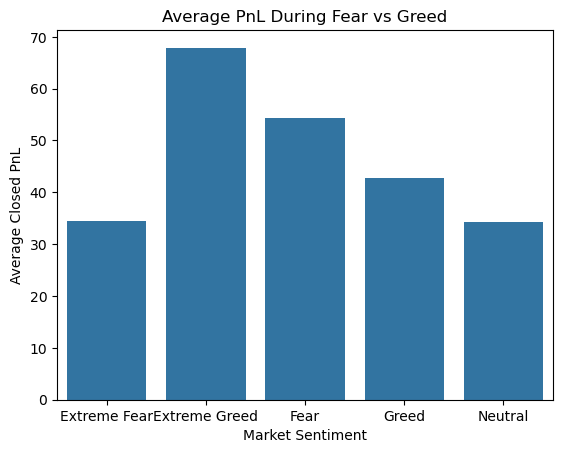

In [50]:
sns.barplot(data=pnl_by_sentiment, x='classification', y='Closed PnL')
plt.title("Average PnL During Fear vs Greed")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.show()

### Insight 2: Trading Activity During Fear vs Greed
Here we compare the number of trades made during Fear and Greed days.
This helps us understand if traders become more active depending on market sentiment.

In [52]:
trade_frequency

,classification,number_of_trades
0,Extreme Fear,21400
1,Extreme Greed,39992
2,Fear,61837
3,Greed,50303
4,Neutral,37686


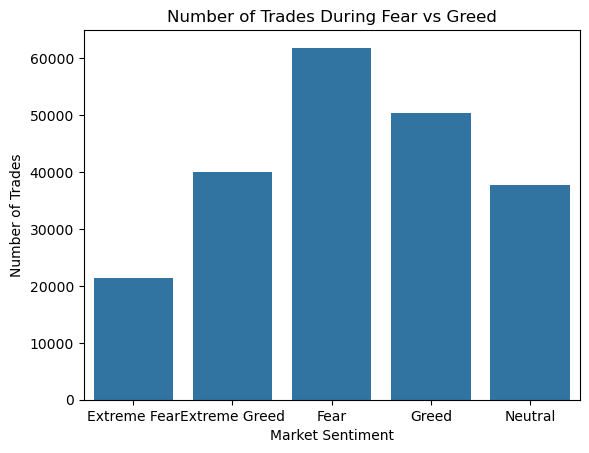

In [53]:
sns.barplot(data=trade_frequency, x='classification', y='number_of_trades')
plt.title("Number of Trades During Fear vs Greed")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.show()

## Insight 3: Trade Size During Fear vs Greed
We compare the average trade size during Fear and Greed days.
This helps us see if traders take larger positions when the market sentiment changes.

In [55]:
avg_trade_size_sentiment

,classification,Size USD
0,Extreme Fear,5349.731843
1,Extreme Greed,3112.251565
2,Fear,7816.109931
3,Greed,5736.884375
4,Neutral,4782.732661


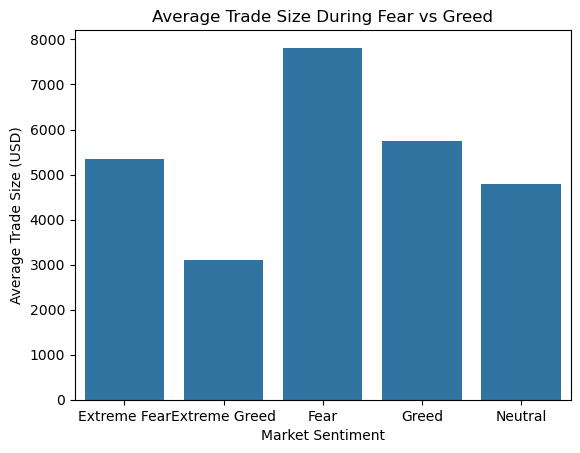

In [56]:
sns.barplot(data=avg_trade_size_sentiment, x='classification', y='Size USD')
plt.title("Average Trade Size During Fear vs Greed")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")
plt.show()

# Part C — “Actionable output”

### Strategy 1: Trade More Selectively During Fear Periods
During Fear days, traders may face higher uncertainty and potential losses. 
A possible strategy is to reduce the number of trades and focus only on strong trading opportunities during these periods.

### Strategy 2: Follow Market Direction Bias
If analysis shows that traders open more long positions during Greed days, traders can align their positions with the general market direction. 
For example, traders may prefer long positions during Greed periods and become more cautious during Fear periods.

### Strategy 3: Manage Position Sizes Based on Market Conditions
The results suggest that trade sizes can vary depending on market sentiment.  
During Greed periods, traders may take slightly larger positions when market confidence is higher.  
During Fear periods, reducing position sizes may help manage risk and avoid large losses.

## Simple Predictive Model (Optional)

As an optional extension, a simple predictive model can be created to estimate trader profitability.

Using available features such as market sentiment, trade size, and trade direction, we attempt to predict whether a trade will result in profit or loss.

This model provides a basic example of how market sentiment and trader behavior could be used for predictive analysis.

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Create target variable (profit or loss)
merged_df['profit_label'] = merged_df['Closed PnL'].apply(lambda x: 1 if x > 0 else 0)

# Convert categorical columns
model_df = merged_df[['classification','Size USD','Side','profit_label']].copy()
model_df = pd.get_dummies(model_df, drop_first=True)

# Features and target
X = model_df.drop('profit_label', axis=1)
y = model_df['profit_label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.71      0.71      0.71     24802
           1       0.59      0.59      0.59     17443

    accuracy                           0.66     42245
   macro avg       0.65      0.65      0.65     42245
weighted avg       0.66      0.66      0.66     42245



In [61]:
sample_trade = pd.DataFrame([[5000,1,0,0,1,0]], columns=X.columns)
model.predict(sample_trade)

array([0], dtype=int64)